# Random Walks

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import scipy

In [57]:
steps = 20
runs = 5
Z = np.random.choice([-1, 1], (steps, runs))
#print(Z)
Y = np.cumsum(Z, axis=0)
Y = np.insert(Y, 0, [0]*runs, axis=0)
#print(Y)

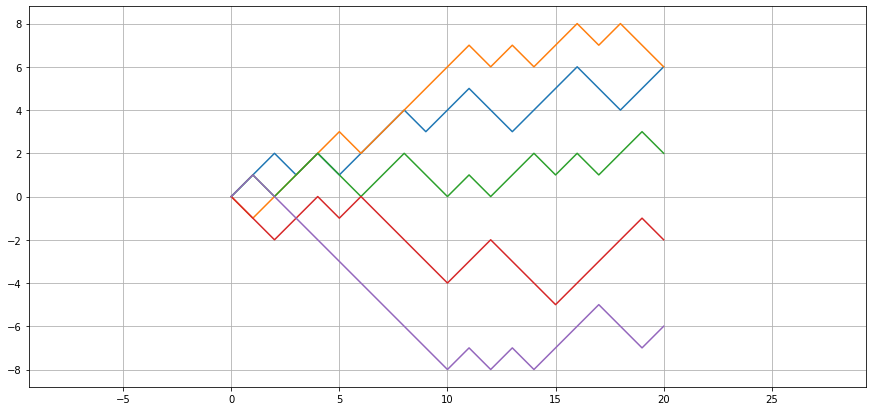

In [58]:
plt.rcParams["figure.figsize"] = (15,7)
plt.axis("equal")
# plt.xticks(range(11))
plt.grid(True)

_ = plt.plot(Y, label="Symmetric Random Walk")
# plt.plot([], [], ' ', label="$\omega=HTHHTTTHTH$\ne.g. $\omega_3=H$ so $X_3=1$")
# plt.legend(fontsize=16)
#print(Y)
#print(Z)

# Scaled Random Walk

In [61]:
T = 8
N = 1000
runs = 5
choices = [-1/np.sqrt(N), 1/np.sqrt(N)]
W = np.cumsum(np.random.choice(choices, (N*T-1, runs)), axis=0)
W = np.insert(W, 0, [0]*runs, axis=0)
X = np.linspace(0, T, T*N)

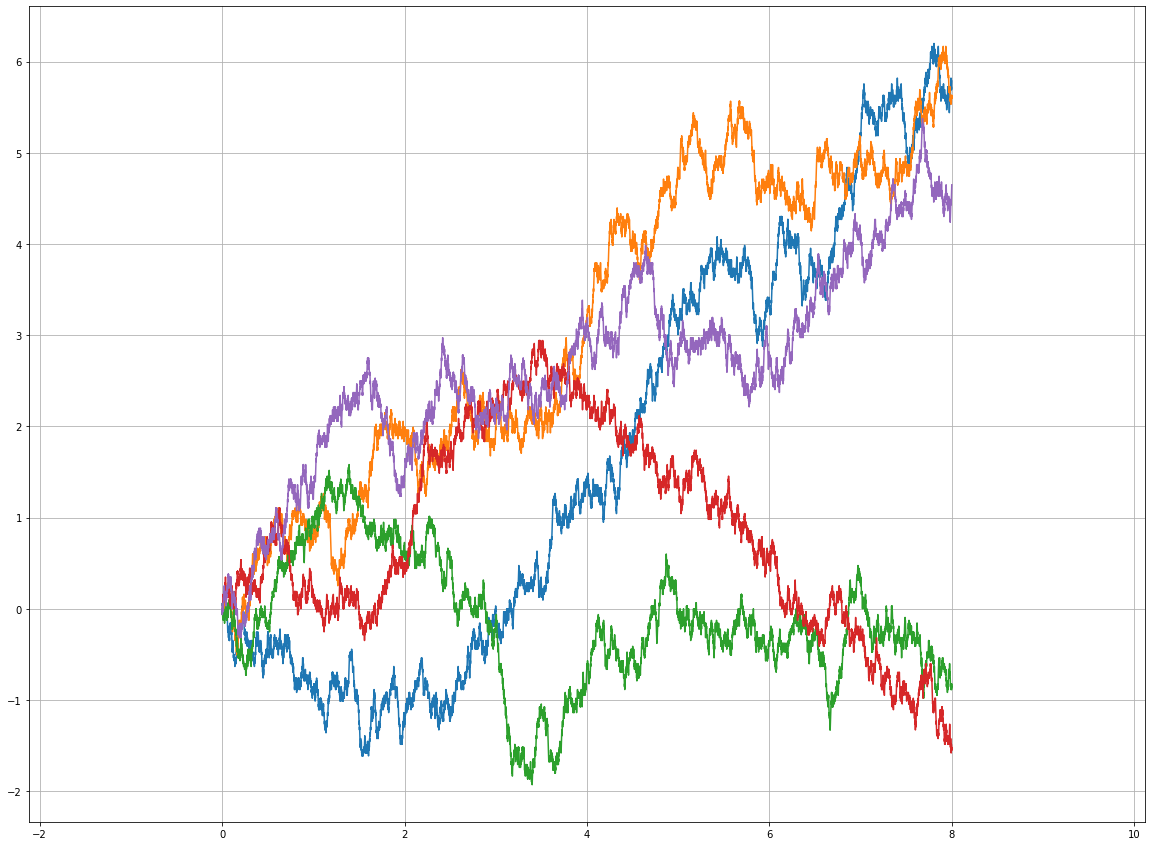

In [62]:
_ = plt.plot(X, W)
plt.axis("equal")
plt.grid(True)
# _ = plt.xticks(range(9))
# plt.plot([], [], ' ', label="$T=8$ and $n=16$")
# plt.legend(fontsize=16)
plt.rcParams["figure.figsize"] = (20,15)

In [63]:
hits = pd.Series(W[-1, :])
hits.describe()
print(f"Time: {T}\tVariance: {hits.var():.3f}")

Time: 8	Variance: 13.101


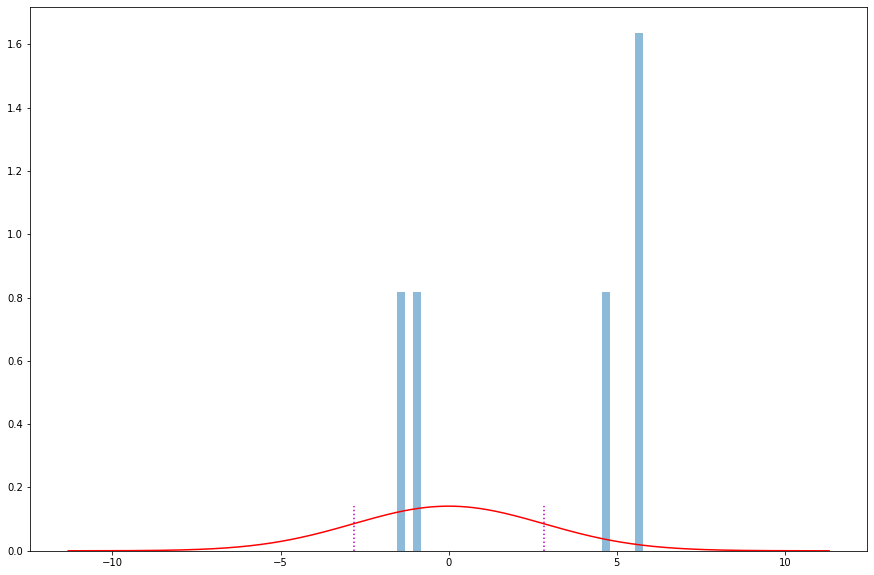

In [64]:
plt.rcParams["figure.figsize"] = (15,10)
plt.hist(hits, bins=30, density=True, alpha=0.5)

stdev = np.sqrt(T)
# plotting +/- 4 standard deviations should be adequate
normX = np.linspace(-4*stdev, 4*stdev, 1000)
normY = [stats.norm.pdf(x, scale=stdev) for x in normX]
plt.plot(normX, normY, 'r-')
plt.vlines(np.sqrt(8), 0, 0.14, 'm', 'dotted')
plt.vlines(-np.sqrt(8), 0, 0.14, 'm', 'dotted')